In [9]:
# =============================================================================
# PHASE 8 (FINAL ROBUST VERSION): Data Assembly, Cleaning, Features, & Splitting
# =============================================================================
import pandas as pd
import numpy as np
import json
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import shap

print("\n" + "="*60)
print("Phase 8 (Robust): Assembling and Cleaning Final Modeling Data")
print("="*60)

# STEP 1: LOAD THE KEY ARTIFACTS
P7_DIR = Path("outputs/phase07")
P3_DIR = Path("outputs/phase03/tables")

labels_df = pd.read_csv(P7_DIR / "resume_labels.csv")
skills_data = []
with open(P3_DIR / "resumes_skills.jsonl", 'r', encoding='utf-8') as f:
    for line in f:
        skills_data.append(json.loads(line))
skills_df = pd.DataFrame(skills_data)
skills_df['skills_text'] = skills_df['skills'].apply(lambda x: ' '.join(x))

# STEP 2: CREATE THE MASTER DATAFRAME
master_df = pd.DataFrame({
    'resume_id': labels_df['resume_id'].astype(str),
    'label_confidence': labels_df['label_confidence'],
    'ontology_role_id': labels_df['ontology_role_id'],
    'skills_text': skills_df['skills_text']
})
print(f"✓ Created master DataFrame with {len(master_df)} records.")

# STEP 3: FILTER FOR THE HIGH-CONFIDENCE TRAINING DATA
model_df = master_df[master_df['label_confidence'] == 'high_confidence'].copy()
print(f"✓ Filtered to a set of {len(model_df)} high-confidence records.")

# --- Start of the FINAL FIX ---
# STEP 4: REMOVE SINGLETON CLASSES (CRUCIAL FOR STRATIFICATION)
print("\nChecking for and removing classes with only one member...")
class_counts = model_df['ontology_role_id'].value_counts()
single_member_classes = class_counts[class_counts < 2].index

if len(single_member_classes) > 0:
    print(f"  - Identified {len(single_member_classes)} singleton classes. Removing them.")
    # Keep only the rows where the class is NOT a singleton
    model_df = model_df[~model_df['ontology_role_id'].isin(single_member_classes)]
    print(f"✓ Final modeling set size after cleaning: {len(model_df)} records.")
else:
    print("  - No singleton classes found. No records removed.")

# --- End of the FINAL FIX ---

# STEP 5: CREATE THE NON-LEAKY FEATURE MATRIX (X) and TARGET VECTOR (y)
if model_df.empty:
    raise ValueError("The modeling DataFrame is empty after cleaning. Cannot proceed.")

skill_vectorizer = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1, 2)
)

X = skill_vectorizer.fit_transform(model_df['skills_text'])
y = model_df['ontology_role_id']

print(f"\n✓ Created feature matrix X with shape: {X.shape}")
print(f"✓ Created target vector y with length: {len(y)}")

# STEP 6: SPLIT THE DATA INTO TRAINING AND TEST SETS
# This will now succeed because all classes in 'y' have at least 2 members.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20,
    random_state=42, 
    stratify=y
)

print(f"\n✓ Training set size: {X_train.shape[0]}")
print(f"✓ Test set size: {X_test.shape[0]}")


Phase 8 (Robust): Assembling and Cleaning Final Modeling Data
✓ Created master DataFrame with 1200 records.
✓ Filtered to a set of 224 high-confidence records.

Checking for and removing classes with only one member...
  - Identified 8 singleton classes. Removing them.
✓ Final modeling set size after cleaning: 216 records.

✓ Created feature matrix X with shape: (216, 879)
✓ Created target vector y with length: 216

✓ Training set size: 172
✓ Test set size: 44


In [10]:
# ================================
# Cell: Train the Logistic Regression Model
# ================================
from sklearn.linear_model import LogisticRegression

print("\n" + "="*60)
print("Training the Logistic Regression Model")
print("="*60)

# Initialize the model with parameters that are good for this type of problem
# - `multi_class='multinomial'` is suitable for multi-class classification.
# - `class_weight='balanced'` helps the model pay more attention to rarer classes.
# - `random_state=42` ensures the results are reproducible.
# - `solver='lbfgs'` is a standard and robust optimization algorithm.
# - `max_iter=1000` gives the model enough iterations to converge.
model = LogisticRegression(
    multi_class='multinomial',
    class_weight='balanced',
    random_state=42,
    solver='lbfgs',
    max_iter=1000
)

# Train the model on the training data we created in the previous cell
print("Fitting the model on the training data...")
model.fit(X_train, y_train)

print("\n✓ Model training complete.")


Training the Logistic Regression Model
Fitting the model on the training data...

✓ Model training complete.


c:\Users\naikt\OneDrive\Desktop\tanmay_dissertation\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [11]:
# ================================
# Cell: Evaluate Model Performance on the Test Set
# ================================
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
from pathlib import Path

print("\n" + "="*60)
print("Evaluating Model Performance on the Unseen Test Set")
print("="*60)

# STEP 1: Get the model's predictions for the test set.
# We use `predict_proba` to get the probability for every possible class.
y_pred_proba = model.predict_proba(X_test)

# STEP 2: Get the class labels in the exact order the model uses them.
# This is crucial for matching probabilities to the correct role IDs.
class_labels = model.classes_

# STEP 3: Define helper functions for ranking metrics.
# (These are standard implementations for Top-K, MRR, and nDCG)
def top_k_accuracy(y_true, y_pred_proba, classes, k=1):
    top_k_preds = np.argsort(y_pred_proba, axis=1)[:, -k:]
    top_k_labels = classes[top_k_preds]
    
    matches = np.any(top_k_labels == y_true.to_numpy()[:, np.newaxis], axis=1)
    return np.mean(matches)

def mean_reciprocal_rank(y_true, y_pred_proba, classes):
    ranks = []
    sorted_indices = np.argsort(y_pred_proba, axis=1)[:, ::-1]
    sorted_labels = classes[sorted_indices]
    
    for i, true_label in enumerate(y_true):
        try:
            rank = np.where(sorted_labels[i] == true_label)[0][0] + 1
            ranks.append(1 / rank)
        except IndexError:
            ranks.append(0) # The true label was not in the predictions
    return np.mean(ranks)

def ndcg_at_k(y_true, y_pred_proba, classes, k=5):
    dcgs = []
    sorted_indices = np.argsort(y_pred_proba, axis=1)[:, ::-1]
    sorted_labels = classes[sorted_indices]
    
    for i, true_label in enumerate(y_true):
        relevance = (sorted_labels[i, :k] == true_label).astype(int)
        dcg = np.sum(relevance / np.log2(np.arange(2, k + 2)))
        # IDCG is always 1 in this case since there's only one relevant item
        idcg = 1.0
        dcgs.append(dcg / idcg)
    return np.mean(dcgs)

# STEP 4: Calculate and print the performance metrics.
top_1_acc = top_k_accuracy(y_test, y_pred_proba, class_labels, k=1)
top_3_acc = top_k_accuracy(y_test, y_pred_proba, class_labels, k=3)
top_5_acc = top_k_accuracy(y_test, y_pred_proba, class_labels, k=5)
mrr = mean_reciprocal_rank(y_test, y_pred_proba, class_labels)
ndcg_5 = ndcg_at_k(y_test, y_pred_proba, class_labels, k=5)

print(f"Top-1 Accuracy: {top_1_acc:.4f}")
print(f"Top-3 Accuracy: {top_3_acc:.4f}")
print(f"Top-5 Accuracy: {top_5_acc:.4f}")
print(f"Mean Reciprocal Rank (MRR): {mrr:.4f}")
print(f"nDCG@5: {ndcg_5:.4f}")

# STEP 5: Save the results to a file for your dissertation.
OUTDIR = Path("outputs/phase08")
OUTDIR.mkdir(parents=True, exist_ok=True)
report_df = pd.DataFrame({
    'metric': ['Top-1 Accuracy', 'Top-3 Accuracy', 'Top-5 Accuracy', 'MRR', 'nDCG@5'],
    'score': [top_1_acc, top_3_acc, top_5_acc, mrr, ndcg_5]
})
report_df.to_csv(OUTDIR / "classification_report.csv", index=False)
print(f"\n✓ Saved classification report to {OUTDIR / 'classification_report.csv'}")


Evaluating Model Performance on the Unseen Test Set
Top-1 Accuracy: 0.3409
Top-3 Accuracy: 0.8182
Top-5 Accuracy: 0.8864
Mean Reciprocal Rank (MRR): 0.5745
nDCG@5: 0.6406

✓ Saved classification report to outputs\phase08\classification_report.csv



Generating SHAP Explanations for Model Interpretability

Generating global feature importance plot...


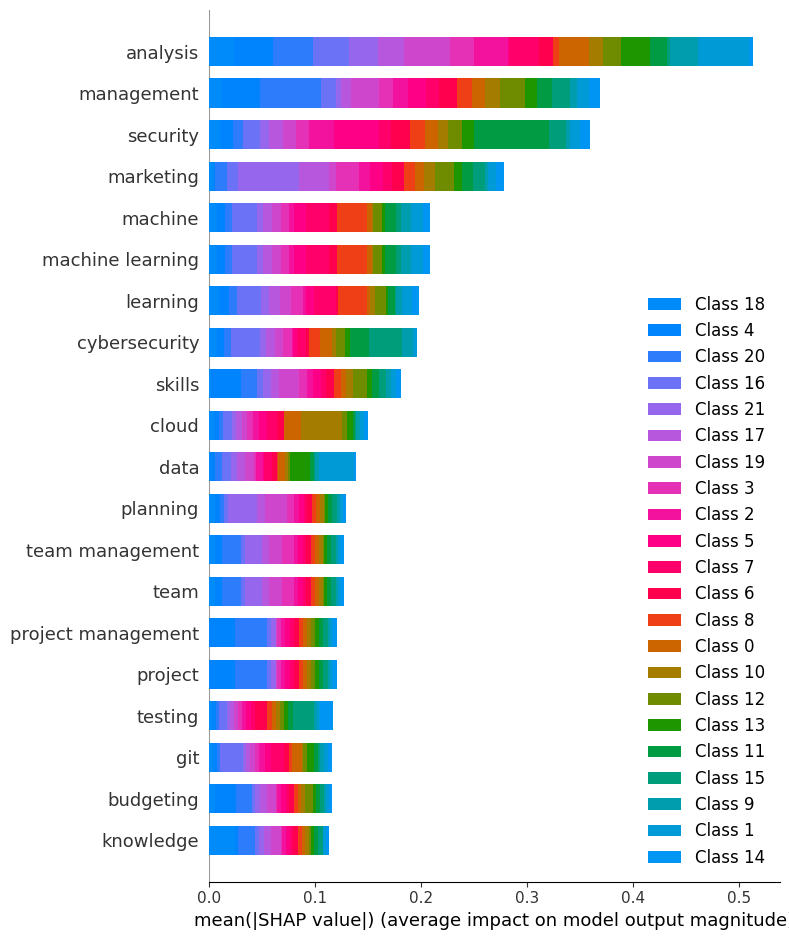

<Figure size 640x480 with 0 Axes>

✓ Saved and displayed global SHAP summary plot.

Generating local explanation for the first test sample...
Explaining prediction for sample 0. Predicted Role ID: 427


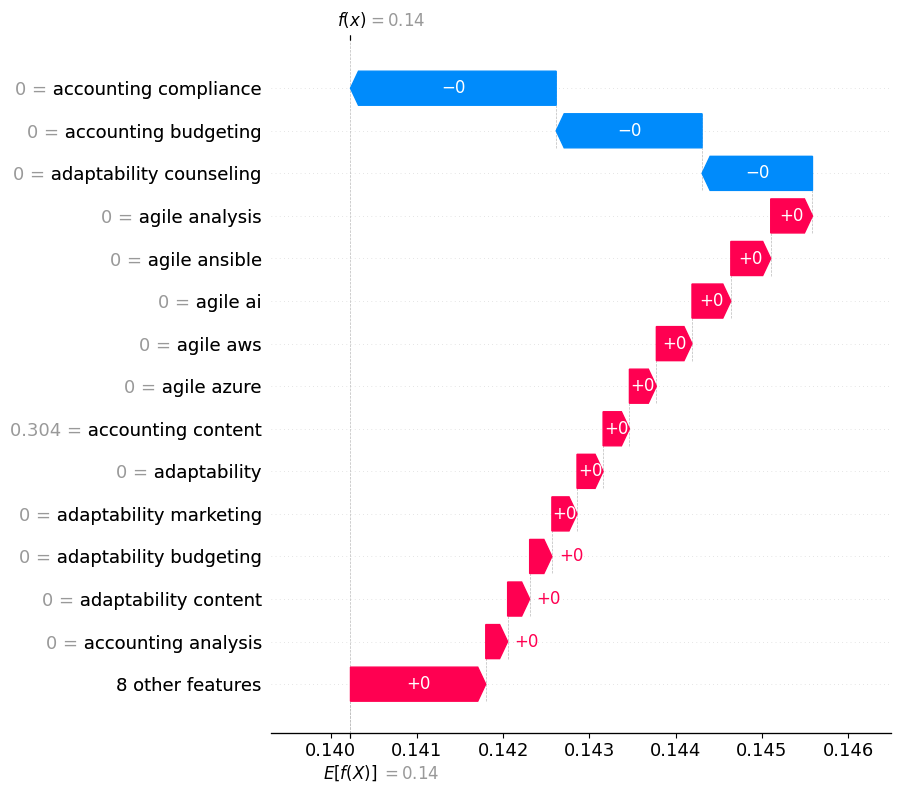

✓ Saved and displayed local SHAP waterfall plot.


In [12]:
# ================================
# Cell: Generate and Visualize SHAP Explanations
# ================================
import shap
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("Generating SHAP Explanations for Model Interpretability")
print("="*60)

# STEP 1: Create the SHAP explainer object.
# We use a LinearExplainer because our model is a Logistic Regression.
# We pass it the model and our training data as a background reference.
explainer = shap.LinearExplainer(model, X_train)

# STEP 2: Calculate the SHAP values for all samples in our test set.
shap_values = explainer.shap_values(X_test)

# STEP 3: Get the feature names (the skills) from our vectorizer.
feature_names = skill_vectorizer.get_feature_names_out()

# =======================================================
# 1. GLOBAL FEATURE IMPORTANCE: What skills are most important overall?
# =======================================================
print("\nGenerating global feature importance plot...")

# The summary plot shows the overall impact of each feature.
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names, max_display=20, plot_type="bar")

# Save and show the plot
global_save_path = OUTDIR / "shap_summary_global.png"
plt.savefig(global_save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"✓ Saved and displayed global SHAP summary plot.")

# =======================================================
# 2. LOCAL EXPLANATION: Why was a specific prediction made?
# =======================================================
print("\nGenerating local explanation for the first test sample...")

# Let's explain the prediction for the first sample in our test set.
sample_index = 0

# Get the index of the class that was predicted for this sample.
predicted_class_index = np.argmax(y_pred_proba[sample_index])

# Get the actual name (role ID) of the predicted class.
predicted_class_label = model.classes_[predicted_class_index]

print(f"Explaining prediction for sample {sample_index}. Predicted Role ID: {predicted_class_label}")

# Create a waterfall plot. This is a great way to see how each skill
# contributed to pushing the prediction towards or away from the final outcome.
plt.figure()
shap.waterfall_plot(shap.Explanation(
    values=shap_values[predicted_class_index][sample_index],
    base_values=explainer.expected_value[predicted_class_index],
    data=X_test[sample_index].toarray().flatten(),
    feature_names=feature_names
), max_display=15, show=False) # Use show=False to customize before displaying

# Save and show the plot
local_save_path = OUTDIR / "shap_waterfall_local.png"
plt.savefig(local_save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"✓ Saved and displayed local SHAP waterfall plot.")

In [15]:
# =======================================================
# FINAL CELL (ROBUST & CORRECTED): The Skill-Gap Analysis Engine
# =======================================================
import pandas as pd
import json
from pathlib import Path

print("\n" + "="*60)
print("Building and Demonstrating the Skill-Gap Analysis Engine")
print("="*60)

# STEP 1: Load the necessary data for the engine
ONTOLOGY_PATH = Path("outputs/phase04/role_skills_ontology.csv")
ontology_df = pd.read_csv(ONTOLOGY_PATH)
ontology_df['skills_ont'] = ontology_df['skills_ont'].apply(json.loads)
print("✓ Loaded ontology with skills.")

# --- Start of the FINAL, ROBUST FIX ---

# --- NEW, SIMPLER Skill-Gap Function ---
def analyze_skill_gap(candidate_skills_set, target_role_id_int, ontology_df):
    """
    Analyzes the skill gap for a given set of candidate skills against a target role.
    This version takes the skills directly, avoiding any brittle ID lookups.
    """
    print(f"\n--- Analyzing Skill Gap ---")
    print(f"  - Target Role ID: {target_role_id_int}")

    # 1. Get the required skills from the ontology for the target role
    try:
        target_role_info = ontology_df[ontology_df['role_id'] == target_role_id_int]
        required_skills = set(target_role_info['skills_ont'].iloc[0])
        target_role_title = target_role_info['role_title'].iloc[0]
        print(f"  - Target Role: {target_role_title}")
    except IndexError:
        print(f"[ERROR] Could not find the specified target_role_id: {target_role_id_int} in the ontology.")
        return
        
    # 2. Calculate the skill gap
    missing_skills = required_skills - candidate_skills_set
    
    print(f"\n  - Candidate has {len(candidate_skills_set)} unique skills.")
    print(f"  - Target role requires {len(required_skills)} core skills.")
    
    if not missing_skills:
        print("\n✓ Congratulations! This candidate possesses all core skills for this role.")
    else:
        print(f"\n! Skill Gap Identified: {len(missing_skills)} core skills are missing.")
        print("  - Missing skills (sample):")
        for i, skill in enumerate(sorted(list(missing_skills))[:10], 1): # Show up to 10
            print(f"    {i}. {skill}")
            
    return

# --- DEMONSTRATION ---
# Let's run the engine on the sample we just explained with SHAP.
# We will use the first resume from our test set (position 0).
sample_position = 0

# Get the original record for this test sample from our 'model_df'.
# We need its skills_text.
# .loc is used to get the row by its original index label.
original_index_label = y_test.index[sample_position]
test_sample_info = model_df.loc[original_index_label]

# Get the candidate's skills directly from the 'skills_text' column and convert to a set.
candidate_skills = set(test_sample_info['skills_text'].split())

# Get the role that was actually predicted by the model for this sample.
predicted_class_index = np.argmax(y_pred_proba[sample_position])
predicted_role_id = int(model.classes_[predicted_class_index])

# Run the new, more robust analysis function
analyze_skill_gap(
    candidate_skills_set=candidate_skills,
    target_role_id_int=predicted_role_id,
    ontology_df=ontology_df
)
# --- End of the FINAL, ROBUST FIX ---


Building and Demonstrating the Skill-Gap Analysis Engine
✓ Loaded ontology with skills.

--- Analyzing Skill Gap ---
  - Target Role ID: 427
  - Target Role: KNOWLEDGE MANAGER

  - Candidate has 10 unique skills.
  - Target role requires 4 core skills.

! Skill Gap Identified: 4 core skills are missing.
  - Missing skills (sample):
    1. Collaboration
    2. Documentation
    3. Information Architecture
    4. Knowledge Management


In [16]:
# ================================
# FINAL CELL in Phase 8: Save Model and Vectorizer
# ================================
import joblib
from pathlib import Path

print("\n" + "="*60)
print("Saving the Final Model and Vectorizer")
print("="*60)

# Define the output directory for Phase 8 artifacts
P8_DIR = Path("outputs/phase08")
P8_DIR.mkdir(parents=True, exist_ok=True)

# Save the trained Logistic Regression model
model_path = P8_DIR / "logistic_regression_model.pkl"
joblib.dump(model, model_path)
print(f"✓ Model saved to: {model_path}")

# Save the fitted TfidfVectorizer
vectorizer_path = P8_DIR / "skill_vectorizer.pkl"
joblib.dump(skill_vectorizer, vectorizer_path)
print(f"✓ Vectorizer saved to: {vectorizer_path}")


Saving the Final Model and Vectorizer
✓ Model saved to: outputs\phase08\logistic_regression_model.pkl
✓ Vectorizer saved to: outputs\phase08\skill_vectorizer.pkl
